<!-- COLAB-BADGE -->
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/brendanpshea/computing_concepts_python/blob/main/v2/notebooks/COMP1150_NB09_Databases.ipynb)  
[Download .ipynb](https://raw.githubusercontent.com/brendanpshea/computing_concepts_python/main/v2/notebooks/COMP1150_NB09_Databases.ipynb) · [View on GitHub](https://github.com/brendanpshea/computing_concepts_python/blob/main/v2/notebooks/COMP1150_NB09_Databases.ipynb)


# Notebook 9: Databases — Where Data Lives When the Program Stops
### COMP 1150 — Computer Science Concepts
**Brendan Shea, PhD**

<!-- Lecture video link to be added -->
📺 **Lecture video:** *(coming soon)*

## Learning Outcomes

By the end of this notebook, you will be able to:

- Explain what a database is and why programs use one instead of variables, spreadsheets, or plain files
- Describe the relational model: tables, rows, columns, primary keys, and foreign keys
- Write basic SQL: `CREATE TABLE`, `INSERT`, `SELECT` with `WHERE` and `ORDER BY`, `JOIN`, and `GROUP BY`
- Explain what an integrity constraint protects against, and why a database that says "no" is a feature
- Distinguish relational from document (non-relational) data models, and argue which fits a given problem

*Maps to course LOs: 9*

## The Problem: Batch 88 Goes Missing

The **Marchpane Confectionery Works** is famous for candies that shouldn't be possible: Gloomberry Fizzers, Thundermint Bars, Whispering Toffee that hums when you unwrap it. Its founder, **Cordelia Marchpane**, is a brilliant inventor — and, until this week, a terrible record-keeper.

Every fact about the factory lives in one enormous spreadsheet started by Cordelia's grandmother. Candies, recipes, batches, shop orders — all of it, in one grid, edited by whoever grabs the laptop first.

This week, three things went wrong at once:

1. A clerk renamed "Gloomberry Fizzer" to "Gloomberry Fizzers" in row 40 — but not in rows 87, 210, or 384. Now searches for the candy find *some* of its records.
2. The Puddleton Sweet Shoppe received 400 boxes of Thundermint Bars. They ordered Whispering Toffee.
3. Batch 88 failed a quality check, and **nobody can say which recipe version it used** — the batch row just says "the usual one."

Cordelia's floor manager, **Hazel Nougat**, delivers the verdict: *"The problem isn't that we made mistakes. Everyone makes mistakes. The problem is that nothing stopped us."*

The spreadsheet will accept anything: a duplicated candy, a misspelled name, an order pointing at a product that doesn't exist. It has no rules, no memory of who changed what, and no way for two people to work safely at once.

There's one more problem, and it's the deepest one. Every program you've written in this course so far had the same quiet flaw: **when the program stopped, its data vanished.** Every list, every dictionary, every object — gone the moment the cell finished. A factory can't work that way. Data has to *outlive* the program that created it.

The tool that fixes all of this — the rules, the sharing, and the surviving — is a **database**. That's what this notebook is about.

### The Roadmap

Here's where we're going:

1. **Why a database?** What the spreadsheet can't do, and the idea of the *relational model*.
2. **Talking to a database** — a language called SQL, and how to create and fill tables.
3. **Asking questions** — `SELECT`, the query that does most of the world's data work.
4. **Two tables are better than one** — `JOIN`, `GROUP BY`, and the safety rules that would have saved Batch 88.
5. **When rows don't fit** — document databases, for data that refuses to sit in neat columns.

At the end, you'll design and build a small database of your own, with an AI assistant doing the typing and you doing the thinking.

## 1. Why a Database? From One Big Grid to Tables

A **database** is an organized collection of data, managed by a program whose whole job is to keep that data correct, shared, and permanent. That program is called a **database management system** (DBMS). The one we'll use is **SQLite** — small, free, and built into Python, but a genuine database used in phones, browsers, and airplanes.

The most successful way to organize a database — dominant for fifty years — is the **relational model**. Its core move sounds almost too simple:

**Give each *kind* of thing its own table.**

Candies are one kind of thing, so they get a `candies` table. Batches are a different kind of thing: `batches` table. Shop orders: `shop_orders` table. Cordelia's grandmother crammed all three into one grid, and that's precisely why every disaster happened.

### The Vocabulary of Tables

Four words carry the whole relational model:

- A **table** holds every record of one kind of thing (all the candies, and *only* candies).
- A **row** is one of those things (one candy: Thundermint Bar).
- A **column** is one fact recorded about every row (every candy has a `price_pence`).
- The **primary key** is a column holding a unique, unchanging ID for each row — a name tag that never lies.

That last one is the fix for the Gloomberry disaster. Names get misspelled, renamed, and duplicated. So a table never uses a name to identify anything. Candy #3 is candy #3 forever, even if its name changes in exactly one place: its own row.

### Picture It: The Factory's Tables

The diagram below shows the three tables we'll build for the Marchpane Works, and how they connect. Each box is a table; each line inside it is a column. The arrows show rows in one table pointing at rows in another — a batch *belongs to* a candy, and so does an order.

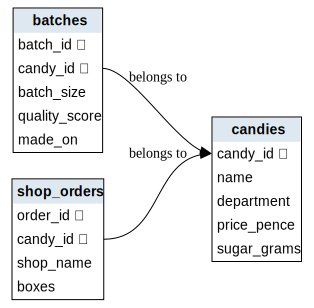

In [1]:
#| echo: false
#@title 📊 Diagram: the factory's tables (click to show code)
import graphviz

er = graphviz.Digraph()
er.attr(rankdir="LR", bgcolor="transparent")
er.attr("node", shape="none", fontname="Helvetica")

def table_node(name, title, rows):
    body = "".join(
        f'<TR><TD ALIGN="LEFT" PORT="{r.split()[0]}">{r}</TD></TR>' for r in rows
    )
    label = ('<<TABLE BORDER="1" CELLBORDER="0" CELLSPACING="0" CELLPADDING="4">'
             + f'<TR><TD BGCOLOR="#dde8f0"><B>{title}</B></TD></TR>'
             + body + "</TABLE>>")
    er.node(name, label)

table_node("candies", "candies",
    ["candy_id 🔑", "name", "department", "price_pence", "sugar_grams"])
table_node("batches", "batches",
    ["batch_id 🔑", "candy_id ↗", "batch_size", "quality_score", "made_on"])
table_node("orders", "shop_orders",
    ["order_id 🔑", "candy_id ↗", "shop_name", "boxes"])

er.edge("batches:candy_id", "candies:candy_id", label="belongs to")
er.edge("orders:candy_id", "candies:candy_id", label="belongs to")
er

**Reading it:** each box is a table and each line is a column. The 🔑 marks the primary key — the row's permanent ID. The arrows (↗) show that `batches` and `shop_orders` don't store a candy's *name*; they store its `candy_id`, pointing back at exactly one row in `candies`. Rename the candy there, and every batch and order follows automatically.

### 💭 Think About It — You Used Five Databases Before Breakfast

Your phone's contacts, your text messages, your streaming history, your school's registration system, the till at the coffee shop — every one is a database.

Pick one system you used today. What do you think its tables are? What would go wrong if it were one big spreadsheet that anyone could edit?

## 2. Talking to a Database: SQL

Databases speak their own language: **SQL** ("ess-cue-ell," or "sequel"), short for *Structured Query Language*. It's been the standard since the 1970s, and it's wonderfully unlike Python: instead of telling the computer *how* to do something step by step, you describe *what* you want, and the database figures out how.

In this notebook we'll write SQL directly in code cells, using a small tool called **jupysql**. Any cell that starts with the line `%%sql` speaks SQL instead of Python. That first line is called a *cell magic* — think of it as a sign on the door saying which language is spoken inside.

The next cell installs the tool. It takes a few seconds and only needs to run once per session.

In [2]:
%pip install jupysql --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pythonw.exe -m pip install --upgrade pip


### Connecting to a Database

With the tool installed, two lines get us ready. The general pattern is:

```
%load_ext sql
%sql sqlite:///file_name.db
```

The first line switches on SQL support. The second connects to a database *file* — and here's a quiet superpower: if the file doesn't exist, SQLite simply creates it. The next cell connects us to `candy_factory.db`, the file where everything we build will live — and where it will **still be** after the program stops.

In [3]:
%load_ext sql
%config SqlMagic.displaylimit = 20
%sql sqlite:///candy_factory.db

Connecting to 'sqlite:///candy_factory.db'

### Making a Table: CREATE TABLE

The first SQL statement to learn creates a table. The general shape is:

```
CREATE TABLE table_name (
    column_name   TYPE,
    column_name   TYPE,
    ...
);
```

You name the table, then list each column with its **data type**. SQLite's everyday types are `INTEGER` (whole numbers), `REAL` (decimals), and `TEXT` (strings). Adding `PRIMARY KEY` after a column marks it as the table's permanent ID.

The next cell builds Cordelia's `candies` table. (The `DROP TABLE IF EXISTS` line first deletes any old copy, so you can safely re-run the cell.)

In [4]:
%%sql
DROP TABLE IF EXISTS candies;

CREATE TABLE candies (
    candy_id     INTEGER PRIMARY KEY,
    name         TEXT,
    department   TEXT,
    price_pence  INTEGER,
    sugar_grams  REAL
);

Running query in 'sqlite:///candy_factory.db'

++
||
++
++

### Understanding the Code

- `%%sql` on the first line means: this whole cell is SQL, not Python.
- `CREATE TABLE candies ( ... )` declares the table and its five columns.
- `candy_id INTEGER PRIMARY KEY` — every candy gets a unique whole-number ID. This is the name tag that never lies.
- Statements end with a semicolon `;` — SQL's version of a full stop.

The table exists, but it's empty — a labeled filing cabinet with no files. Let's fix that.

### Filling It: INSERT

Adding a row uses `INSERT`. The general shape:

```
INSERT INTO table_name (column_1, column_2, ...)
VALUES (value_1, value_2, ...);
```

You name the columns, then supply one value for each, in the same order. Text values go in single quotes: `'Thundermint Bar'`. The next cell stocks the factory's catalog.

In [5]:
%%sql
INSERT INTO candies (candy_id, name, department, price_pence, sugar_grams) VALUES
    (1, 'Gloomberry Fizzer',   'Fizzworks',    120, 22.0),
    (2, 'Thundermint Bar',     'Chocolate',    250, 31.5),
    (3, 'Whispering Toffee',   'Toffee Hall',  180, 27.0),
    (4, 'Marchpane Original',  'Marzipanery',  300, 18.5),
    (5, 'Puddle Drops',        'Fizzworks',     90, 12.0),
    (6, 'Candied Thistle',     'Experimental', 210,  8.0),
    (7, 'Hummingbird Nougat',  'Toffee Hall',  260, 24.5),
    (8, 'Midnight Sherbet',    'Fizzworks',    140, 19.0);

Running query in 'sqlite:///candy_factory.db'

8 rows affected.

++
||
++
++

Eight candies, one `INSERT`. (Listing several rows after one `VALUES`, separated by commas, is a handy shortcut.)

But did it work? Time to meet the most important word in SQL. The next cell asks the database to show us everything in the table.

In [6]:
%%sql
SELECT * FROM candies;

Running query in 'sqlite:///candy_factory.db'

candy_id,name,department,price_pence,sugar_grams
1,Gloomberry Fizzer,Fizzworks,120,22.0
2,Thundermint Bar,Chocolate,250,31.5
3,Whispering Toffee,Toffee Hall,180,27.0
4,Marchpane Original,Marzipanery,300,18.5
5,Puddle Drops,Fizzworks,90,12.0
6,Candied Thistle,Experimental,210,8.0
7,Hummingbird Nougat,Toffee Hall,260,24.5
8,Midnight Sherbet,Fizzworks,140,19.0


There's the whole catalog, back out of the database as a clean table. `SELECT * FROM candies` means "give me every column (`*`) of every row in `candies`."

Notice what you did *not* have to write: no loop, no print formatting, no file handling. You described what you wanted; the database did the rest. The whole next section is about asking sharper questions than "everything, please."

### ✏️ Your Turn — Cordelia's Ingredient Stores

Cordelia wants a table for raw ingredients. It needs: an `ingredient_id` (whole number, primary key), a `name` (text), `stock_kg` (a decimal — how much is in the storeroom), and `cost_pence_per_kg` (a whole number).

Write the `CREATE TABLE` statement, then `INSERT` at least three ingredients. Invent something suitably strange — lifting syrup, powdered thunder, gloomberries.

In [7]:
#| eval: false
%%sql
-- TODO: create the ingredients table (4 columns, described above)


-- TODO: insert at least three ingredients

## 3. Asking Questions: Barnaby and the Tasting Bureau

**Barnaby Brittle** runs the factory's Tasting Bureau, and he lives inside one SQL word: `SELECT`. Creating tables happens once; *querying* them happens thousands of times a day, everywhere. A request for data is called a **query**.

The full shape of a basic query:

```
SELECT column_1, column_2
FROM table_name
WHERE condition;
```

- `SELECT` — *which columns* you want (or `*` for all of them).
- `FROM` — *which table* to look in.
- `WHERE` — *which rows* qualify. Leave it off, and you get every row.

Barnaby rarely needs every column. The next cell pulls just names and prices.

In [8]:
%%sql
SELECT name, price_pence
FROM candies;

Running query in 'sqlite:///candy_factory.db'

name,price_pence
Gloomberry Fizzer,120
Thundermint Bar,250
Whispering Toffee,180
Marchpane Original,300
Puddle Drops,90
Candied Thistle,210
Hummingbird Nougat,260
Midnight Sherbet,140


Two columns instead of five — `SELECT` lets you take only what you need.

Filtering *rows* is where queries get powerful. A `WHERE` condition works like the boolean tests you've written in Python: `=`, `<`, `>`, combined with `AND` and `OR`. (One trap for Python speakers: SQL tests equality with a single `=`, not `==`.)

Barnaby has been asked for the *lighter* end of the catalog. The next cell finds every candy under 20 grams of sugar.

In [9]:
%%sql
SELECT name, sugar_grams
FROM candies
WHERE sugar_grams < 20;

Running query in 'sqlite:///candy_factory.db'

name,sugar_grams
Marchpane Original,18.5
Puddle Drops,12.0
Candied Thistle,8.0
Midnight Sherbet,19.0


Four rows survive the filter. The database checked the condition against every candy and kept only the ones where it was true — exactly like an `if` inside a loop, except you never wrote the loop.

Conditions combine just like in Python. `WHERE department = 'Fizzworks' AND price_pence < 100` finds cheap fizzy candies. `OR` and `NOT` work too.

### 🔮 Predict Before You Run

The next cell asks for candies where `department = 'Fizzworks' AND sugar_grams < 20`.

Look back at the full catalog printout above. **Before you run the cell**, write down which candies you expect — and how many rows that is.

In [10]:
%%sql
SELECT name, department, sugar_grams
FROM candies
WHERE department = 'Fizzworks' AND sugar_grams < 20;

Running query in 'sqlite:///candy_factory.db'

name,department,sugar_grams
Puddle Drops,Fizzworks,12.0
Midnight Sherbet,Fizzworks,19.0


Did you predict both? Gloomberry Fizzer is in Fizzworks but has 22 grams of sugar — the `AND` requires *both* conditions, so it's out.

One more tool and Barnaby's kit is complete: **sorting**. Add these to the end of a query:

```
ORDER BY column_name DESC
LIMIT n;
```

`ORDER BY` sorts the results by a column (`DESC` for descending, highest first; leave it off for ascending). `LIMIT` keeps only the first *n* rows. Together they answer "top three" questions — like the next cell: the factory's three most expensive candies.

In [11]:
%%sql
SELECT name, price_pence
FROM candies
ORDER BY price_pence DESC
LIMIT 3;

Running query in 'sqlite:///candy_factory.db'

name,price_pence
Marchpane Original,300
Hummingbird Nougat,260
Thundermint Bar,250


Sorted, trimmed, done. Notice the pattern of everything in this section: you *describe the result* — these columns, rows matching this, in this order, only this many — and the database works out the steps. That's SQL's whole personality.

### ✏️ Your Turn — Barnaby's Shortlist

The Tasting Bureau needs a shortlist for a "light and affordable" gift box: every candy **under 25 grams of sugar**, showing `name`, `price_pence`, and `sugar_grams`, **sorted from cheapest to most expensive**.

One query does it. (Remember: ascending is the default sort.)

In [12]:
#| eval: false
%%sql
-- TODO: Barnaby's shortlist — under 25g sugar, cheapest first
SELECT

## 4. Two Tables Are Better Than One

Back to the week's disasters. The renamed Gloomberry Fizzer broke the spreadsheet because the candy's *name* was copied into hundreds of rows. The relational fix: other tables store the candy's **primary key**, never its name.

When a column in one table holds the primary key of another table's row, it's called a **foreign key**. A batch doesn't say "the usual one" — it says `candy_id = 3`, which points at exactly one row in `candies`, forever.

The next cell builds the factory's two remaining tables. Watch the `FOREIGN KEY` lines — and the `PRAGMA` at the top, which switches on SQLite's enforcement of them.

In [13]:
%%sql
PRAGMA foreign_keys = ON;

DROP TABLE IF EXISTS batches;
CREATE TABLE batches (
    batch_id      INTEGER PRIMARY KEY,
    candy_id      INTEGER,
    batch_size    INTEGER,
    quality_score REAL,
    made_on       TEXT,
    FOREIGN KEY (candy_id) REFERENCES candies (candy_id)
);

DROP TABLE IF EXISTS shop_orders;
CREATE TABLE shop_orders (
    order_id   INTEGER PRIMARY KEY,
    candy_id   INTEGER,
    shop_name  TEXT,
    boxes      INTEGER,
    FOREIGN KEY (candy_id) REFERENCES candies (candy_id)
);

Running query in 'sqlite:///candy_factory.db'

++
||
++
++

### Understanding the Code

- Each table gets its own primary key (`batch_id`, `order_id`).
- `candy_id INTEGER` — the foreign key column. It holds *numbers*, not names.
- `FOREIGN KEY (candy_id) REFERENCES candies (candy_id)` — the rule: any value in this column **must** exist as a primary key in `candies`.
- `PRAGMA foreign_keys = ON` — SQLite politely ignores that rule unless you switch enforcement on. We want it on. We'll see why shortly.

Now some data: recent batches off the line, and the week's shop orders.

In [14]:
%%sql
INSERT INTO batches (batch_id, candy_id, batch_size, quality_score, made_on) VALUES
    (86, 2, 500, 9.1, '2026-06-29'),
    (87, 5, 800, 8.4, '2026-06-30'),
    (88, 1, 650, 5.2, '2026-07-01'),
    (89, 3, 400, 9.6, '2026-07-01'),
    (90, 1, 700, 8.9, '2026-07-02');

INSERT INTO shop_orders (order_id, candy_id, shop_name, boxes) VALUES
    (501, 3, 'Puddleton Sweet Shoppe', 400),
    (502, 2, 'Puddleton Sweet Shoppe', 120),
    (503, 1, 'The Sugared Quill',      250),
    (504, 4, 'The Sugared Quill',       60),
    (505, 2, 'Grimble & Daughters',    300),
    (506, 5, 'Grimble & Daughters',    450);

Running query in 'sqlite:///candy_factory.db'

5 rows affected.

6 rows affected.

++
||
++
++

### Putting Them Back Together: JOIN

Look at `batches`: it's all ID numbers. Efficient — but Hazel can't hand Cordelia a report that says "candy 1 had a bad day." We need each batch *with its candy's name*. Recombining tables is what `JOIN` does:

```
SELECT columns
FROM table_a
JOIN table_b ON table_a.key_column = table_b.key_column;
```

The `ON` clause says how rows match up: a batch and a candy belong together when their `candy_id` values are equal. Because both tables have a column called `candy_id`, we write the table name in front — `batches.candy_id` — to say which one we mean.

The next cell produces Hazel's readable batch report.

In [15]:
%%sql
SELECT batches.batch_id, candies.name, batches.quality_score
FROM batches
JOIN candies ON batches.candy_id = candies.candy_id
ORDER BY batches.quality_score;

Running query in 'sqlite:///candy_factory.db'

batch_id,name,quality_score
88,Gloomberry Fizzer,5.2
87,Puddle Drops,8.4
90,Gloomberry Fizzer,8.9
86,Thundermint Bar,9.1
89,Whispering Toffee,9.6


Every batch, with its candy's *name* — even though `batches` never stores a name. The database matched each batch's `candy_id` to the right row of `candies` and stitched the columns together on the fly.

And there's the week's mystery solved in one line of output: **Batch 88, Gloomberry Fizzer, quality 5.2.** The ID pointed at exactly one candy. No "the usual one" possible.

This is the deal the relational model offers: store every fact **once**, in the table where it belongs — then use `JOIN` to recombine facts whenever a question needs them.

### Ledger's Question: GROUP BY

**Ledger Pettigrew** in accounts doesn't want rows; he wants *totals*. Which candy earned the most this week? That takes two new tools:

```
SELECT column, SUM(expression)
FROM ...
GROUP BY column;
```

`GROUP BY` gathers rows into buckets — one bucket per candy. An **aggregate function** then boils each bucket down to one number: `SUM()` adds, `COUNT()` counts, `AVG()` averages.

The next cell joins orders to candies, groups by candy, and totals up the money.

In [16]:
%%sql
SELECT candies.name,
       SUM(shop_orders.boxes) AS total_boxes,
       SUM(shop_orders.boxes * candies.price_pence) AS revenue_pence
FROM shop_orders
JOIN candies ON shop_orders.candy_id = candies.candy_id
GROUP BY candies.name
ORDER BY revenue_pence DESC;

Running query in 'sqlite:///candy_factory.db'

name,total_boxes,revenue_pence
Thundermint Bar,420,105000
Whispering Toffee,400,72000
Puddle Drops,450,40500
Gloomberry Fizzer,250,30000
Marchpane Original,60,18000


One row per candy, not per order — that's `GROUP BY` at work. The `AS` keyword just gives a calculated column a readable name.

Ledger's entire quarterly report is queries like this one. So is a streaming service's "most played," a hospital's "visits per patient," and a game's leaderboard. `JOIN` + `GROUP BY` is most of what "data analysis" means in practice.

### Hazel's Safety Rule

One disaster remains: the Puddleton shipment — an order pointing at the wrong product. The spreadsheet accepted it silently. What does the database do?

A rule like `FOREIGN KEY` is an **integrity constraint**: a promise about the data that the database itself enforces. Not a warning. A refusal.

The next cell tries to log a batch for candy #999 — a candy that does not exist. It's marked not to run automatically, because it is *designed to fail*. Run it yourself and read the error.

In [17]:
#| eval: false
%%sql
-- This INSERT is designed to FAIL. Run it and read the error message.
INSERT INTO batches (batch_id, candy_id, batch_size, quality_score, made_on)
VALUES (91, 999, 500, 7.0, '2026-07-03');

You should see an error ending in **`FOREIGN KEY constraint failed`**.

Hazel's verdict on the spreadsheet was: *"nothing stopped us."* This is what stopping us looks like. The database checked `candies` for a candy #999, found nothing, and rejected the row — no matter who typed it, no matter how busy the factory was.

That's the deep difference between a spreadsheet and a database. A spreadsheet stores what you typed. A database enforces what must be *true*.

### ✏️ Your Turn — Hazel's Quality Watchlist

Hazel wants a watchlist: the **candy name**, **batch ID**, and **quality score** for every batch scoring **below 9.0**, worst first.

You'll need a `JOIN` (the names live in `candies`, the scores in `batches`), a `WHERE`, and an `ORDER BY`. Use the batch report query above as your model.

In [18]:
#| eval: false
%%sql
-- TODO: Hazel's watchlist — name, batch_id, quality_score for batches under 9.0, worst first
SELECT

### 💭 Think About It — The Machine That Says No

The foreign-key error *prevented* a user from doing what they asked. Usually we call that a bug. Here it's the whole point.

Where else should software refuse an instruction, even from an authorized user? Where would a hard "no" do more harm than good? Who should get to decide which rules are unbreakable?

## 5. When Rows Don't Fit: Juniper's Flavor Dreams

**Juniper Quist** runs Experimental Flavors, and her data problem is different in kind. The factory invites the public to submit "flavor dreams" — descriptions of candies they wish existed. The submissions are chaos:

- One dreamer specifies a texture, a color, and a sound.
- Another lists fourteen allergies and a childhood memory.
- Another writes only: *"make it taste like a thunderstorm."*

Try designing a table for that. What are the columns? `texture`? `memory`? `sound_on_unwrapping`? Every submission would fill three columns and leave forty empty — and next week someone invents a field you never imagined. Rigid columns, which *saved* the factory in sections 1–4, are exactly wrong here.

### The Document Model

The alternative: store each submission as a **document** — a free-form bundle of labeled data, usually written as **JSON** (JavaScript Object Notation). JSON should look eerily familiar; it's essentially a Python dictionary in text form:

```
{"from": "a dreamer", "wants": ["fizzy", "purple"], "loudness": 3}
```

A **document database** stores one document per record and lets every document have a *different shape*. Famous examples include MongoDB; these systems are often grouped under the banner **NoSQL** ("not only SQL").

We don't need new software to try the idea — SQLite can store JSON in an ordinary `TEXT` column and query inside it. The next cell files three wildly different dreams.

In [19]:
%%sql
DROP TABLE IF EXISTS flavor_dreams;
CREATE TABLE flavor_dreams (
    dream_id  INTEGER PRIMARY KEY,
    dream     TEXT
);

INSERT INTO flavor_dreams (dream_id, dream) VALUES
    (1, '{"from": "Milo, age 9", "taste": "thunderstorm", "loudness": 5}'),
    (2, '{"from": "Prof. Anemone", "texture": "cloud", "color": "in-between blue",
          "allergies": ["nuts", "regret"]}'),
    (3, '{"from": "anonymous", "taste": "the last day of school",
          "must_hum": true, "budget_pence": 200}');

Running query in 'sqlite:///candy_factory.db'

3 rows affected.

++
||
++
++

Three rows, three completely different shapes — and the table didn't complain, because to the table each dream is just one text value. No empty columns, no `ALTER TABLE` every time a dreamer invents a new field.

Can we still *query* inside them? SQLite provides `json_extract(column, '$.field')`, which reaches into a document and pulls out one labeled value (the `$` means "start at the top of the document"). The next cell pulls out who each dream is from, and its taste — if it has one.

In [20]:
%%sql
SELECT dream_id,
       json_extract(dream, '$.from')  AS dreamer,
       json_extract(dream, '$.taste') AS taste
FROM flavor_dreams;

Running query in 'sqlite:///candy_factory.db'

dream_id,dreamer,taste
1,"Milo, age 9",thunderstorm
2,Prof. Anemone,None
3,anonymous,the last day of school


Notice Prof. Anemone's `taste` comes back as `None` — her dream simply doesn't have that field, and the document model shrugs: fine.

That shrug is the whole trade-off. Compare the two models honestly:

| | Relational (tables) | Document (JSON) |
|---|---|---|
| Every record has the same shape? | Yes — enforced | No — each document differs |
| Rules like foreign keys? | Strong, automatic | Weak or manual |
| Combining data (`JOIN`)? | Excellent | Awkward |
| Handles surprise fields? | Painfully (`ALTER TABLE`) | Effortlessly |
| Best when… | the shape is known and shared | the shape is varied and evolving |

The rule of thumb: **batches and bank accounts want tables; dreams and profiles want documents.** Real systems — including this factory — often use both, side by side.

### ✏️ Your Turn — Pick the Right Model

For each scenario, choose **relational** or **document** — and give one sentence of *why*, using the table above. There's a defensible case on both sides for at least one of them.

1. A bank's ledger of account transfers.
2. Player save-files for a video game, where every update adds new abilities and items.
3. A clinic's records of patients, visits, and prescriptions.
4. An online shop's product catalog: books, gloves, kayaks — each with different attributes.

No code for this one — write your four answers in the cell below or on paper.

*(Write your answers here — double-click this cell to edit it.)*

1.
2.
3.
4.

### 💭 Think About It — Queryable Isn't the Same as Fair Game

Juniper realizes she can run one query and read every dream ever submitted — including names, allergies, and childhood memories people typed in without much thought.

Databases make data *easy to ask about*. Does being able to query something give you the right to? Who should be allowed to run which queries at the factory — and who decides?

## 6. How a *Program* Talks to the Database

The `%%sql` magic is a tool for humans in notebooks. Real applications — a shop website, the factory's ordering app — are programs, and they run SQL through an ordinary library. Python ships with one: `sqlite3`.

The pattern is only three moves: **connect** to the database file, **execute** a query, **fetch** the results. The next cell is plain Python, reading the same `candy_factory.db` we've been building all along.

In [21]:
import sqlite3

connection = sqlite3.connect("candy_factory.db")
rows = connection.execute(
    "SELECT name, price_pence FROM candies ORDER BY price_pence DESC LIMIT 3"
).fetchall()
connection.close()

for name, price in rows:
    print(f"{name}: {price}p")

Marchpane Original: 300p
Hummingbird Nougat: 260p
Thundermint Bar: 250p


Same SQL, same answers — the language doesn't change, only who's speaking it. The query went in as a string; the results came back as a plain Python list you can loop over.

Hold onto this pattern. Next notebook, we'll build a small **web application**, and this is exactly how it will work: a browser asks a question, a few lines of Python run a query, and the database — the permanent, rule-enforcing memory underneath everything — supplies the answer.

## SQL Quick Reference: The Card on the Wall

Cordelia keeps a laminated card taped beside the factory terminal — every command the Marchpane Works actually uses, with a working example of each. This is that card.

Two bits of official vocabulary make the card easier to organize. Commands that shape the *tables themselves* are called **DDL** (*data definition language*). Commands that change or read the *rows inside them* are called **DML** (*data manipulation language*). You've been using both all along — the card just sorts them.

Every example below runs against this notebook's own tables. Paste any of them into a `%%sql` cell above and experiment.

### Defining Structure (DDL)

These commands create and reshape tables — the filing cabinets, not the files.

| Keyword | What it does | Example |
|---|---|---|
| `CREATE TABLE` | makes a new table with named, typed columns | `CREATE TABLE staff (staff_id INTEGER PRIMARY KEY, name TEXT);` |
| `DROP TABLE IF EXISTS` | deletes a table and everything in it | `DROP TABLE IF EXISTS staff;` |
| `ALTER TABLE ... ADD COLUMN` | adds a column to an existing table | `ALTER TABLE candies ADD COLUMN is_seasonal INTEGER;` |

`ALTER TABLE` is the command Juniper's flavor dreams were rescuing us from: with rigid columns, every newly invented field means altering the table for *every* row.

### Changing Data (DML)

These commands add, edit, and remove rows.

| Keyword | What it does | Example |
|---|---|---|
| `INSERT INTO ... VALUES` | adds new rows | `INSERT INTO candies (candy_id, name, department, price_pence, sugar_grams) VALUES (9, 'Fizzing Humbug', 'Fizzworks', 150, 21.0);` |
| `UPDATE ... SET ... WHERE` | edits matching rows | `UPDATE candies SET price_pence = 130 WHERE name = 'Gloomberry Fizzer';` |
| `DELETE FROM ... WHERE` | removes matching rows | `DELETE FROM candies WHERE candy_id = 9;` |

⚠️ **The classic disaster:** on `UPDATE` and `DELETE`, the `WHERE` clause chooses *which* rows. Forget it, and you change — or delete — **every row in the table**. Databases do exactly what you ask. Ask carefully.

### Asking Questions (Queries)

The `SELECT` family — most of the SQL anyone writes, most days.

| Keyword | What it does | Example |
|---|---|---|
| `SELECT ... FROM` | choose columns from a table | `SELECT name, price_pence FROM candies;` |
| `WHERE` | keep only matching rows | `SELECT name FROM candies WHERE sugar_grams < 20;` |
| `ORDER BY ... DESC` | sort results (DESC = highest first) | `SELECT name, price_pence FROM candies ORDER BY price_pence DESC;` |
| `LIMIT` | keep only the first *n* results | `SELECT name FROM candies ORDER BY price_pence DESC LIMIT 3;` |
| `JOIN ... ON` | recombine two tables by matching keys | `SELECT candies.name, batches.quality_score FROM batches JOIN candies ON batches.candy_id = candies.candy_id;` |
| `GROUP BY` | gather rows into buckets for totals | `SELECT candy_id, COUNT(*) FROM batches GROUP BY candy_id;` |
| `COUNT / SUM / AVG` | boil a bucket down to one number | `SELECT AVG(quality_score) FROM batches;` |
| `AS` | rename a result column | `SELECT name, price_pence AS price FROM candies;` |

### Types and Rules

The building blocks inside a `CREATE TABLE`.

| Keyword | What it does | Example |
|---|---|---|
| `INTEGER` / `REAL` / `TEXT` | column types: whole numbers / decimals / text | `sugar_grams REAL` |
| `PRIMARY KEY` | this column is the row's unique, permanent ID | `candy_id INTEGER PRIMARY KEY` |
| `FOREIGN KEY ... REFERENCES` | values here must exist as a key in another table | `FOREIGN KEY (candy_id) REFERENCES candies (candy_id)` |
| `NOT NULL` | this column may never be left empty | `name TEXT NOT NULL` |
| `PRAGMA foreign_keys = ON` | tells SQLite to actually enforce foreign keys | `PRAGMA foreign_keys = ON;` |

**Not covered here, but you'll meet them:** `DISTINCT` (drop duplicate results), `HAVING` (a `WHERE` for groups), and `CREATE INDEX` (make lookups on a column faster). When you see them in the wild, you'll know they're friends.

Keep the card handy — the capstone below is where you'll want it.

## ✏️ Capstone — The Sweetshop Database

Time to build your own. You'll design a small database and have an AI assistant (Gemini, Claude, or ChatGPT) write the SQL — while *you* make every design decision and verify every result.

**The default theme:** you've opened a small sweetshop that stocks Marchpane candies. You need three tables: your products, your suppliers, and your sales. **Or reskin it entirely** — a record shop, your game collection, a plant nursery, a recipe box. Any theme with 2–3 kinds of connected things works.

### Step 0 — Design First (before touching the AI)

In the cell below, write your design as plain text:

- Your 2–3 tables, and what one *row* of each represents
- The columns of each table, with types
- Where the primary keys are, and which column is a **foreign key** pointing at which table

*(Double-click and write your design here.)*

**Table 1:** ...

**Table 2:** ...

**Table 3:** ...

### Step 1 — Build It *(prompt #1)*

Turn your design into a prompt. A skeleton to fill in:

> I'm learning SQL with SQLite in a Jupyter notebook, using `%%sql` cell magic.
> Write `CREATE TABLE` statements for these tables: **[paste your design]**.
> Include `PRIMARY KEY` and `FOREIGN KEY` constraints, and start with `DROP TABLE IF EXISTS` lines.
> Then write `INSERT` statements adding **[5–10]** realistic rows per table, themed around **[your theme]**.
> SQL only, one code block, no explanations.

Paste the AI's SQL into the cell below and run it. If it errors, read the message — fix it yourself or ask the AI, but *you* decide what changes.

In [22]:
#| eval: false
%%sql
-- ✏️ Paste your AI-built CREATE TABLE and INSERT statements here, then run.

### Step 2 — Interrogate It *(prompt #2)*

Ask the AI for **five queries** against your schema — require at least: one `WHERE` filter, one `ORDER BY ... LIMIT`, one `JOIN`, and one `GROUP BY` with `SUM` or `COUNT`.

**Then verify like Barnaby would:** before running each query, look at your inserted data and predict the answer. Run it. If a result surprises you, figure out whether the query is wrong or your prediction was — one of those happens a lot with AI-written `JOIN`s.

In [23]:
#| eval: false
%%sql
-- ✏️ Paste and run your five queries here (one at a time is fine).

### Step 3 — Break It, Then Reflect

Two final tests:

1. **Try to break your own rules.** Write an `INSERT` that violates one of your foreign keys (like candy #999). Confirm the database refuses it. If it *doesn't*, find out why — did the AI forget the constraint, or is `PRAGMA foreign_keys = ON` missing?
2. **Reflect** in the cell below, 2–3 sentences: What did the AI get wrong or almost-wrong? What did you catch by predicting results first?

*AI is a fast first draft. You verify.*

In [24]:
#| eval: false
%%sql
-- ✏️ Your constraint-breaking INSERT goes here. It SHOULD fail.

*(Your 2–3 sentence reflection — double-click to edit.)*

## Key Terms

- **Aggregate function** — A function like `SUM()`, `COUNT()`, or `AVG()` that boils a group of rows down to one number.
- **Column** — One fact recorded about every row in a table, such as `price_pence`.
- **Database** — An organized, permanent collection of data managed by software that keeps it correct and shareable.
- **DBMS (database management system)** — The program that manages a database and enforces its rules; SQLite is one.
- **DDL (data definition language)** — The SQL commands that shape tables themselves: `CREATE TABLE`, `DROP TABLE`, `ALTER TABLE`.
- **DML (data manipulation language)** — The SQL commands that change or read the rows: `INSERT`, `UPDATE`, `DELETE`, `SELECT`.
- **Document database** — A database that stores free-form documents (usually JSON), letting every record have a different shape.
- **Foreign key** — A column holding the primary key of a row in another table, linking the two.
- **Integrity constraint** — A rule about the data (like a foreign key) that the database itself enforces by refusing bad changes.
- **JOIN** — The SQL operation that recombines rows from two tables by matching key values.
- **JSON** — A text format for labeled, nested data; looks and works much like a Python dictionary.
- **NoSQL** — An umbrella term for non-relational databases, including document stores.
- **Primary key** — A column whose value uniquely and permanently identifies each row in its table.
- **Query** — A request for data, written in SQL with `SELECT`.
- **Relational model** — The design that organizes data into tables of rows and columns, one table per kind of thing.
- **Row** — One record in a table: one candy, one batch, one order.
- **SQL** — Structured Query Language, the standard language for creating, filling, and querying databases.
- **Table** — A named grid holding every record of one kind of thing.


## Summary

A database gives data three things a running program can't: permanence, shared access, and enforced rules. The relational model organizes data as tables — one per kind of thing — where every row has a permanent primary key, and other tables point at it with foreign keys instead of copying names. SQL is the language for all of it: `CREATE TABLE` and `INSERT` to build, `SELECT` with `WHERE`, `ORDER BY`, `JOIN`, and `GROUP BY` to ask questions. Integrity constraints are the database *refusing* to store what must not be true — the safety rule the Marchpane spreadsheet never had. And when data won't sit in fixed columns, document databases trade those rules away for flexibility. Knowing *which trade to make* is the real skill.

## What's Next

Your database can answer questions — but only for someone sitting at this notebook. Next time we go bigger: operating systems, networks, and the web, ending with your first **web application**. A browser anywhere in the world will send a request, and a few lines of Python will answer it — by querying a database, exactly the way you did today.

*COMP 1150 — Computer Science Concepts · Brendan Shea, PhD*
*Content licensed under [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).*